In [13]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib import animation as animation
from matplotlib.patches import Polygon
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch,
                    ZScaleInterval)
import astropy.units as u
from ndcube import NDCube
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs
from fancy_colorbar import wcs_scalebar
from IPython.display import HTML, display
from tqdm.notebook import tqdm
from slit_interactive import plot_slit_position, generate_slit_data_from_points

In [4]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

In [5]:
plt.rcParams.update(ms_style_dict)

In [6]:
# load all plot-ready dataset, including data (in dask arrays), wcs and date_obs

file_Gband_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Gband_AEZDV_pr.hdf5")
Gband_pr_set = file_Gband_pr["vbi_img"]
Gband_pr_da = da.from_array(Gband_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Gband_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Gband_AEZDV_date_avg.txt")["DATE-AVG"])

file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_CaIIK_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/CaIIK_BZPOW_pr.hdf5")
CaIIK_pr_set = file_CaIIK_pr["vbi_img"]
CaIIK_pr_da = da.from_array(CaIIK_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
CaIIK_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/CaIIK_BZPOW_date_avg.txt")["DATE-AVG"])

file_TiO_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/TiO_BNRPZ_pr.hdf5")
TiO_pr_set = file_TiO_pr["vbi_img"]
TiO_pr_da = da.from_array(TiO_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
TiO_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/TiO_BNRPZ_date_avg.txt")["DATE-AVG"])

file_Halpha_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])


file_hri_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_pr.hdf5")
hri_pr_set = file_hri_pr_dset["hrieuv_img"]
hri_pr_da = da.from_array(hri_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))


file_hri_pr_noproj_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_noproj_pr.hdf5")
hri_pr_noproj_array = file_hri_pr_noproj_dset["hrieuv_noproj_img"][:]
hrieuv_no_proj_extent = np.load("../../data/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")
hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("../../data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hrieuv_noproj_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]


hrieuv_date_ear = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])


file_irissji_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/IRISSJI_1400_pr.hdf5")
irissji_pr_set = file_irissji_pr_dset["irissji_1400_img"]
irissji_pr_da = da.from_array(irissji_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
irissji_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/IRISSJI_1400_date_obs.txt")["date_obs"])


file_aia171_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/AIA_171_pr.hdf5")
aia171_pr_set = file_aia171_pr_dset["aia_171_img"]
aia171_pr_da = da.from_array(aia171_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
aia171_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/AIA_171_date_obs.txt")["date_obs"])


dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

target_wcs = dkist_vbi_target_cube_crop.wcs
target_wcs_rebin = dkist_vbi_target_cube_crop_rebin.wcs

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [7]:
# hrieuv_index_ = 94
# iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - irissji_date_obs))
# Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Halpha_date_obs))
# Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Hbeta_date_obs))
# CaIIK_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - CaIIK_date_obs))
# TiO_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - TiO_date_obs))
# Gband_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Gband_date_obs))
# aia171_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - aia171_date_obs))

# print(Halpha_index_)

In [8]:
Hbeta_pr_da.shape

(282, 3840, 3840)

In [9]:
x_select_df1  = np.array(
    [562.8, 512.5, 476.9, 427.0]
)*4

y_select_df1 = np.array(
    [459.5, 478.0, 486.0, 483.3]
)*4

x_select_df1_p = np.array(
    [122, 99.8]
)

y_select_df1_p = np.array(
    [113.5, 93.9]
)

#====================================================================================
x_select_df2 = np.array(
    [380, 336, 246]
)*4

y_select_df2 = np.array(
    [755, 775, 783]
)*4

x_select_df2_p = np.array(
    [92.7, 83.3, 72.9]
)

y_select_df2_p = np.array(
    [197.6, 190.3, 175.5]
)

#====================================================================================
x_select_df3 = np.array(
    [551.5, 533.4, 499.7,]
)*4

y_select_df3 = np.array(
    [626.0, 715.1, 882.8,]
)*4

x_select_df3_p = np.array(
    [127.4, 135.3, 152.6*0.75 + 0.25*183.1]
)

y_select_df3_p = np.array(
    [144.4, 164.8, 180.2*0.75 + 0.25*198.3]
)

#====================================================================================
x_select_df4 = np.array(
    [426, 350.6, 283.6]
)*4

y_select_df4 = np.array(
    [563.8, 535.9, 498.0]
)*4

x_select_df4_p = np.array(
    [98.1, 85.6, 80.6]
)

y_select_df4_p = np.array(
    [127.8, 112.4, 100.3]
)

#====================================================================================
x_select_ef1 = np.array(
    [396, 358, 322.4, 282, 242, 210, 178]
)*4

y_select_ef1 = np.array(
    [461, 433.5, 399, 346, 287, 232, 177]
)*4

x_select_ef1_p = np.array(
    [105.5, 100.1, 83.6, 78.3, 74.7]
)

y_select_ef1_p = np.array(
    [100.8, 93.3, 60.7, 45.4, 33.5]
)



slit_df1_result_dummy = generate_slit_data_from_points(
        x_select_df1, y_select_df1, np.zeros((Hbeta_pr_da.shape[1], Hbeta_pr_da.shape[2], 2)), "NDArray", line_width=10*4,
    )

slit_df1_p_result_dummy = generate_slit_data_from_points(
        x_select_df1_p, y_select_df1_p, np.zeros((Hbeta_pr_da.shape[1]//8, Hbeta_pr_da.shape[2]//8, 2)), "NDArray", line_width=4,
)

slit_df2_result_dummy = generate_slit_data_from_points(
        x_select_df2, y_select_df2, np.zeros((Hbeta_pr_da.shape[1], Hbeta_pr_da.shape[2], 2)), "NDArray", line_width=10*4,
    )

slit_df2_p_result_dummy = generate_slit_data_from_points(
        x_select_df2_p, y_select_df2_p, np.zeros((Hbeta_pr_da.shape[1]//8, Hbeta_pr_da.shape[2]//8, 2)), "NDArray", line_width=4,
)

slit_df3_result_dummy = generate_slit_data_from_points(
        x_select_df3, y_select_df3, np.zeros((Hbeta_pr_da.shape[1], Hbeta_pr_da.shape[2], 2)), "NDArray", line_width=10*4,
    )

slit_df3_p_result_dummy = generate_slit_data_from_points(
        x_select_df3_p, y_select_df3_p, np.zeros((Hbeta_pr_da.shape[1]//8, Hbeta_pr_da.shape[2]//8, 2)), "NDArray", line_width=4,
)

slit_df4_result_dummy = generate_slit_data_from_points(
        x_select_df4, y_select_df4, np.zeros((Hbeta_pr_da.shape[1], Hbeta_pr_da.shape[2], 2)), "NDArray", line_width=10*4,
    )

slit_df4_p_result_dummy = generate_slit_data_from_points(
        x_select_df4_p, y_select_df4_p, np.zeros((Hbeta_pr_da.shape[1]//8, Hbeta_pr_da.shape[2]//8, 2)), "NDArray", line_width=4,
)

slit_ef1_result_dummy = generate_slit_data_from_points(
        x_select_ef1, y_select_ef1, np.zeros((Hbeta_pr_da.shape[1], Hbeta_pr_da.shape[2], 2)), "NDArray", line_width=10*4,
    )

slit_ef1_p_result_dummy = generate_slit_data_from_points(
        x_select_ef1_p, y_select_ef1_p, np.zeros((Hbeta_pr_da.shape[1]//8, Hbeta_pr_da.shape[2]//8, 2)), "NDArray", line_width=4,
)



In [10]:
# matplotlib layout engine does not 
# work very well with WCSAxes with 
# fixed aspect ratios.
# So we need to manually add axes with 
# its [x0, y0, width, height]

w_space = 0.06
h_space = 0.06
left_margin = 0.2
right_margin = 0.04
top_margin = 0.1
bottom_margin = 0.2
fig_size_scale = 2.2
fig_x = (left_margin + 4 + 3*w_space + right_margin) 
fig_y = (top_margin + 3 + 2*h_space + bottom_margin)

In [19]:
def make_movie(
    fps=15,
    dpi=120, 
    save_dir=None,
):

    hrieuv_index_ = 0
    iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - irissji_date_obs))
    Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Halpha_date_obs))
    Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Hbeta_date_obs))
    CaIIK_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - CaIIK_date_obs))
    TiO_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - TiO_date_obs))
    Gband_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Gband_date_obs))
    aia171_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - aia171_date_obs))

    fig = plt.figure(figsize=(fig_x*fig_size_scale, fig_y*fig_size_scale))

    Hbeta_image_ = Hbeta_pr_da[Hbeta_index_].compute()
    hrieuv_no_proj_image_ = hri_pr_noproj_array[hrieuv_index_]
    hrieuv_proj_image_ = hri_pr_da[hrieuv_index_].compute()
    aia_image_ = aia171_pr_da[aia171_index_].compute()
    irissji_image_ = irissji_pr_da[iris_index_].compute()
    Halpha_image_ = Halpha_pr_da[Halpha_index_].compute()
    CaIIK_image_ = CaIIK_pr_da[CaIIK_index_].compute()
    TiO_image_ = TiO_pr_da[TiO_index_].compute()
    Gband_image_ = Gband_pr_da[Gband_index_].compute()

    hrieuv_nt = len(hrieuv_date_ear)

    axes = {}

    axes["A"] = fig.add_axes([left_margin/fig_x, bottom_margin/fig_y,
            (2 + w_space)/fig_x, (2 + h_space)/fig_y],
            projection=unwrap_wcs_to_fitswcs(target_wcs)[0])

    imA = axes["A"].imshow(Hbeta_image_, cmap="Greys_r",
                norm=ImageNormalize(vmin=-0.05, vmax=1.5,
                stretch=AsinhStretch(0.6)),
                interpolation="none", aspect=1, rasterized=True)

    axes["B"] = fig.add_axes([left_margin/fig_x, (bottom_margin + 2 + 2*h_space)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=hrieuv_noproj_wcs)

    imB = axes["B"].imshow(hrieuv_no_proj_image_,
                cmap="solar orbiterhri_euv174",
                interpolation="none", aspect=1, rasterized=True)
    axes["B"].set_anchor((1,0))

    axes["C"] = fig.add_axes([(left_margin + 1 + w_space)/fig_x,
                            (bottom_margin + 2 + 2*h_space)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=target_wcs_rebin)
    imC = axes["C"].imshow(hrieuv_proj_image_,
                cmap="solar orbiterhri_euv174",
                interpolation="none", aspect=1,
                rasterized=True)

    axes["D"] = fig.add_axes([(left_margin + 2 + 2*w_space)/fig_x,
                            (bottom_margin + 2 + 2*h_space)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=target_wcs_rebin)
    imD = axes["D"].imshow(aia_image_, cmap="sdoaia171",
                interpolation="none", aspect=1, rasterized=True)

    axes["E"] = fig.add_axes([(left_margin + 3 + 3*w_space)/fig_x,
                                (bottom_margin + 2 + 2*h_space)/fig_y,
                                1/fig_x, 1/fig_y],
                                projection=target_wcs_rebin)
    imE = axes["E"].imshow(irissji_image_, cmap="irissji1400",
                norm=ImageNormalize(
                    vmin=np.nanpercentile(irissji_image_, 0.5),
                    vmax=np.nanpercentile(irissji_image_, 99.8)
                ),
                interpolation="none", aspect=1, rasterized=True)

    axes["F"] = fig.add_axes([(left_margin + 2 + 2*w_space)/fig_x,
                                (bottom_margin + 1 + h_space)/fig_y,
                                1/fig_x, 1/fig_y],
                                projection=target_wcs)
    imF = axes["F"].imshow(Halpha_image_, cmap="Greys_r",
                norm=ImageNormalize(vmin=0.1, vmax=1.3, stretch=AsinhStretch(0.5)),
                interpolation="none", aspect=1, rasterized=True)

    axes["G"] = fig.add_axes([(left_margin + 3 + 3*w_space)/fig_x,
                            (bottom_margin + 1 + h_space)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=target_wcs)
    imG = axes["G"].imshow(CaIIK_image_, cmap="bone",
                norm=ImageNormalize(vmin=0, vmax=1.3),
                interpolation="none", aspect=1, rasterized=True)

    axes["H"] = fig.add_axes([(left_margin + 2 + 2*w_space)/fig_x,
                            (bottom_margin)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=unwrap_wcs_to_fitswcs(target_wcs)[0])
    imH = axes["H"].imshow(Gband_image_, cmap="irissji2796",
                norm=ImageNormalize(vmin=0, vmax=1),
                interpolation="none", aspect=1, rasterized=True)

    axes["I"] = fig.add_axes([(left_margin + 3 + 3*w_space)/fig_x,
                            (bottom_margin)/fig_y,
                            1/fig_x, 1/fig_y],
                            projection=target_wcs)
    imI = axes["I"].imshow(TiO_image_, cmap="cividis",
                norm=ImageNormalize(vmin=0, vmax=1),
                interpolation="none", aspect=1, rasterized=True)

    for ax_key in {"A", "B", "C", "D", "E", "F", "G", "H", "I"}:
        axes[ax_key].grid(True, color="w", ls=":", lw=0.5, alpha=0.7)

    for ax_key in {"A", "C", "D", "E", "F", "G", "H", "I"}:
        axes[ax_key].set_adjustable("box")

    for ax_key in {"C", "D", "E", "F", "G", "H", "I"}:
        axes[ax_key].coords[0].set_axislabel(" ", size=0, visible=False)
        axes[ax_key].coords[1].set_axislabel(" ", size=0, visible=False)
        axes[ax_key].coords[0].set_ticklabel_visible(False)
        axes[ax_key].coords[1].set_ticklabel_visible(False)

    axes["B"].coords[0].set_axislabel(" ", size=0, visible=False)
    axes["B"].coords[1].set_axislabel(" ", size=0, visible=False)
    axes["B"].coords[0].set_ticks(number=4)
    axes["B"].coords[1].set_ticks(spacing=50*u.arcsec)
    # this bug in astropy 7.1.0 https://github.com/astropy/astropy/issues/18576
    # requires us to manually set the tick label 
    axes["B"].coords[0].set_ticklabel_position("t")

    axes["A"].coords[0].set_axislabel(r"Helioprojective Longitude (Solar-X)", size=11)
    axes["A"].coords[1].set_axislabel(r"Helioprojective Latitude (Solar-Y)", size=11)



    # plt.show(fig)

    def update_fig(ii):

        hrieuv_index_ = ii % hrieuv_nt

        iris_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - irissji_date_obs))
        Halpha_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Halpha_date_obs))
        Hbeta_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Hbeta_date_obs))
        CaIIK_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - CaIIK_date_obs))
        TiO_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - TiO_date_obs))
        Gband_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - Gband_date_obs))
        aia171_index_ = np.nanargmin(np.abs(hrieuv_date_ear[hrieuv_index_] - aia171_date_obs))

        Hbeta_image_ = Hbeta_pr_da[Hbeta_index_].compute()
        hrieuv_no_proj_image_ = hri_pr_noproj_array[hrieuv_index_]
        hrieuv_proj_image_ = hri_pr_da[hrieuv_index_].compute()
        aia_image_ = aia171_pr_da[aia171_index_].compute()
        irissji_image_ = irissji_pr_da[iris_index_].compute()
        Halpha_image_ = Halpha_pr_da[Halpha_index_].compute()
        CaIIK_image_ = CaIIK_pr_da[CaIIK_index_].compute()
        TiO_image_ = TiO_pr_da[TiO_index_].compute()
        Gband_image_ = Gband_pr_da[Gband_index_].compute()

        imA.set_data(Hbeta_image_)
        imB.set_data(hrieuv_no_proj_image_)
        imC.set_data(hrieuv_proj_image_)
        imD.set_data(aia_image_)
        imE.set_data(irissji_image_)
        imF.set_data(Halpha_image_)
        imG.set_data(CaIIK_image_)
        imH.set_data(TiO_image_)
        imI.set_data(Gband_image_)

        if ii == hrieuv_nt:
            for slit_result in (
                slit_df1_result_dummy,
                slit_df2_result_dummy,
                slit_df3_result_dummy,
                slit_df4_result_dummy
                ):
                plot_slit_position(
                    axes["A"],
                    slit_result,
                    show_control_points=False,
                    show_legend=False,
                    show_direction=True,
                    show_curve=False,
                    boundary_color="#7DB9DE",
                    triangle_color="#7DB9DE",
                    triangle_ratio=0.6,
                    triangle_length=100,
                    boundary_width=1.5,
                    boundary_alpha=1.0,
                    curve_alpha=1.0,
                    triangle_alpha=1.0
                )
    
            axes["A"].text(2050, 2150,
                r"\textbf{DF1}", ha="left", va="top", fontsize=11, color="#7DB9DE",
                alpha=1, path_effects=[path_effects.Stroke(linewidth=3, foreground="w"),
                path_effects.Normal()]
                )
            
            axes["A"].text(1100, 3350,
                r"\textbf{DF2}", ha="left", va="top", fontsize=11, color="#7DB9DE",
                alpha=1,
                path_effects=[path_effects.Stroke(linewidth=3, foreground="w"),
                path_effects.Normal()]
                )   

            axes["A"].text(2200, 3100,
                r"\textbf{DF3}", ha="left", va="top", fontsize=11, color="#7DB9DE",
                alpha=1,
                path_effects=[path_effects.Stroke(linewidth=3, foreground="w"),
                path_effects.Normal()]
                ) 

            axes["A"].text(1300, 2400,
                r"\textbf{DF4}", ha="left", va="top", fontsize=11, color="#7DB9DE",
                alpha=1,
                path_effects=[path_effects.Stroke(linewidth=3, foreground="w"),
                path_effects.Normal()]
                ) 



            plot_slit_position(
                axes["A"],
                slit_ef1_result_dummy,
                show_control_points=False,
                show_legend=False,
                show_direction=True,
                show_curve=False,
                boundary_color="#86C166",
                triangle_color="#86C166",
                triangle_ratio=0.6,
                triangle_length=100,
                boundary_width=1.5,
                boundary_alpha=1.0,
                curve_alpha=1.0,
                triangle_alpha=1.0
                )
            
            axes["A"].text(1000, 1750,
                r"\textbf{EF1}", ha="left", va="top", fontsize=11, color="#86C166",
                alpha=1,
                path_effects=[path_effects.Stroke(linewidth=3, foreground="w"),
                path_effects.Normal()]
                )    
            
            roiA_verts = np.array([[50,50], [2048,50],
                [2048, 1536], [1536, 2560],
                [50, 2560], [50, 50]])
            
            axes["A"].text(50+64, 2560 - 64,
                r"\textbf{A}", ha="left", va="top", fontsize=13, color="#E83015",
                alpha=1, path_effects=[path_effects.Stroke(linewidth=2, foreground="w"),
                path_effects.Normal()]
                )

            roiB_verts = np.array([[1536+64, 2560], [3072, 2560],
                [3072, 1200],
                [1536+64 - (2560 - 1200)*(1536 - 2048)/(2560 - 1536),1200]])
            
            axes["A"].text(3072 - 64, 2560 - 64,
                r"\textbf{B}", ha="right", va="top", fontsize=13, color="#E83015",
                alpha=1, path_effects=[path_effects.Stroke(linewidth=2, foreground="w"),
                path_effects.Normal()]
                )

            roiC_verts = np.array([[832, 2560+64], [3608, 2560+64],
                [3608, 3840 - 50], [832, 3840 - 50]])
            
            axes["A"].text(832 + 64, 3840 - 50 - 64,
                r"\textbf{C}", ha="left", va="top", fontsize=13, color="#E83015",
                alpha=1, path_effects=[path_effects.Stroke(linewidth=2, foreground="w"),
                path_effects.Normal()]
                )

            for verts_ in (roiA_verts, roiB_verts, roiC_verts):
                poly_ = Polygon(
                    verts_, closed=True,
                    facecolor='none', 
                    edgecolor='#E83015', lw=2,
                    ls=(0,(5,3)), alpha=0.9,
                    joinstyle='round',
                )

                axes["A"].add_patch(poly_)

            
            sbA = wcs_scalebar(axes["A"], 2*u.Mm, corner="bottom left",
                        label=r"\textbf{2 Mm}",
                        dsun=get_earth(Hbeta_date_obs[Hbeta_index_]).radius,
                        bbox_to_anchor=(0.02, 0.02, 0.15, 0.15),
                        bbox_transform=axes["A"].transAxes,
                        frame=False, 
                        color="white", size_vertical=35,
                        fontproperties={"size": 12},
                        sep=8,
                        pad=0,
                        borderpad=0
                        )
            
            fig.canvas.draw()
            
            sbA.txt_label._text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            sbA.size_bar.get_children()[0].set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            text_date =axes["A"].text(0.98, 0.02,
                        r"\textbf{DKIST/VBI-B H}$\boldsymbol{\beta}$" + \
                            "\n" + \
                        r"\textbf{{{}}}".format(Hbeta_date_obs[Hbeta_index_].strftime("%Y-%m-%dT%H:%M:%S")),
                        ha="right", va="bottom", size=12, color="w",
                        transform=axes["A"].transAxes,
                        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()]
                        )
            
            axes["B"].text(0.98, 0.02,
                        r"\textbf{EUI/HRI\textsubscript{EUV}}",
                        ha="right", va="bottom", size=12, color="w",
                        transform=axes["B"].transAxes,
                        path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                        path_effects.Normal()]
                        )

            sbB = wcs_scalebar(axes["B"], 2*u.Mm, corner="bottom left",
                        label=r"\textbf{2 Mm}",
                        # dsun=get_earth(Hbeta_date_obs[Hbeta_index_]).radius,
                        bbox_to_anchor=(0.02, 0.02, 0.15, 0.15),
                        bbox_transform=axes["B"].transAxes,
                        frame=False, 
                        color="white",
                        size_vertical=35*2*hri_pr_noproj_array[hrieuv_index_].shape[1]/\
                            Hbeta_pr_set[Hbeta_index_].shape[1],
                        fontproperties={"size": 12},
                        sep=8,
                        pad=0,
                        borderpad=0
                        )
            
            fig.canvas.draw()
            
            sbB.txt_label._text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            sbB.size_bar.get_children()[0].set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            for slit_result in (
                slit_df1_p_result_dummy,
                slit_df2_p_result_dummy,
                slit_df3_p_result_dummy,
                slit_df4_p_result_dummy
                ):
                plot_slit_position(
                    axes["B"],
                    slit_result,
                    show_control_points=False,
                    show_legend=False,
                    show_direction=True,
                    show_curve=False,
                    boundary_color="#7DB9DE",
                    triangle_color="#7DB9DE",
                    triangle_ratio=0.6,
                    triangle_length=5,
                    boundary_width=0.8,
                    boundary_alpha=1.0,
                    curve_alpha=1.0,
                    triangle_alpha=1.0
                )
            
            plot_slit_position(
                axes["B"],
                slit_ef1_p_result_dummy,
                show_control_points=False,
                show_legend=False,
                show_direction=True,
                show_curve=False,
                boundary_color="#86C166",
                triangle_color="#86C166",
                triangle_ratio=0.6,
                triangle_length=5,
                boundary_width=0.8,
                boundary_alpha=1.0,
                curve_alpha=1.0,
                triangle_alpha=1.0
                )
            
            axes["C"].text(0.98, 0.02,
                r"\textbf{Reproj. HRI\textsubscript{EUV}}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["C"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )

            axes["D"].text(0.98, 0.02,
                r"\textbf{SDO/AIA 171}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["D"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )

            axes["E"].text(0.98, 0.02,
                r"\textbf{IRIS/SJI 1400}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["E"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )

            axes["F"].text(0.98, 0.02,
                r"\textbf{VBI-R H}$\boldsymbol{\alpha}$",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["F"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )   

            axes["G"].text(0.98, 0.02,
                r"\textbf{VBI-B Ca\,\textsc{ii} K}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["G"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )
            
            axes["H"].text(0.98, 0.02,
                r"\textbf{VBI-B G band}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["H"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )

            sbH = wcs_scalebar(axes["H"], 2*u.Mm, corner="bottom left",
                        label=r"\textbf{2 Mm}",
                        dsun=get_earth(Hbeta_date_obs[Hbeta_index_]).radius,
                        bbox_to_anchor=(0.02, 0.02, 0.3, 0.3),
                        bbox_transform=axes["H"].transAxes,
                        frame=False, 
                        color="white", size_vertical=70,
                        fontproperties={"size": 12},
                        sep=8,
                        pad=0,
                        borderpad=0
                        )
            
            fig.canvas.draw()
            
            sbH.txt_label._text.set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            sbH.size_bar.get_children()[0].set_path_effects([
                path_effects.Stroke(linewidth=2, foreground='black'),
                path_effects.Normal()
            ])

            axes["I"].text(0.98, 0.02,
                r"\textbf{VBI-R TiO}",
                ha="right", va="bottom", size=12, color="w",
                transform=axes["I"].transAxes,
                path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                path_effects.Normal()]
                )

            axes["A"].text(0.02, 0.98, r"\textbf{a)}", ha="left", va="top", size=12, color="w",
                    transform=axes["A"].transAxes,
                    path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                    path_effects.Normal()])
            
            for ax_key in {"B", "C", "D", "E", "F", "G", "H", "I"}:
                axes[ax_key].text(0.04, 0.96, r"\textbf{{{})}}".format(ax_key.lower()),
                    ha="left", va="top", size=12, color="w",
                    transform=axes[ax_key].transAxes,
                    path_effects=[path_effects.Stroke(linewidth=2, foreground="black"),
                    path_effects.Normal()])
        
        if ii > hrieuv_nt:
            text_date.set_text(
                r"\textbf{DKIST/VBI-B H}$\boldsymbol{\beta}$" + \
                "\n" + \
                r"\textbf{{{}}}".format(Hbeta_date_obs[Hbeta_index_].strftime("%Y-%m-%dT%H:%M:%S"))
            )

        
    anim = animation.FuncAnimation(fig, update_fig, frames=tqdm(range(hrieuv_nt)), #range(0,50), #
                                        blit=False)
    
    anim.save(save_dir, fps=fps, dpi=dpi,writer='ffmpeg', 
        codec='libx264',
        # bitrate=6000,
        extra_args=['-pix_fmt', 'yuv420p'])

    return None    

  0%|          | 0/30 [00:00<?, ?it/s]

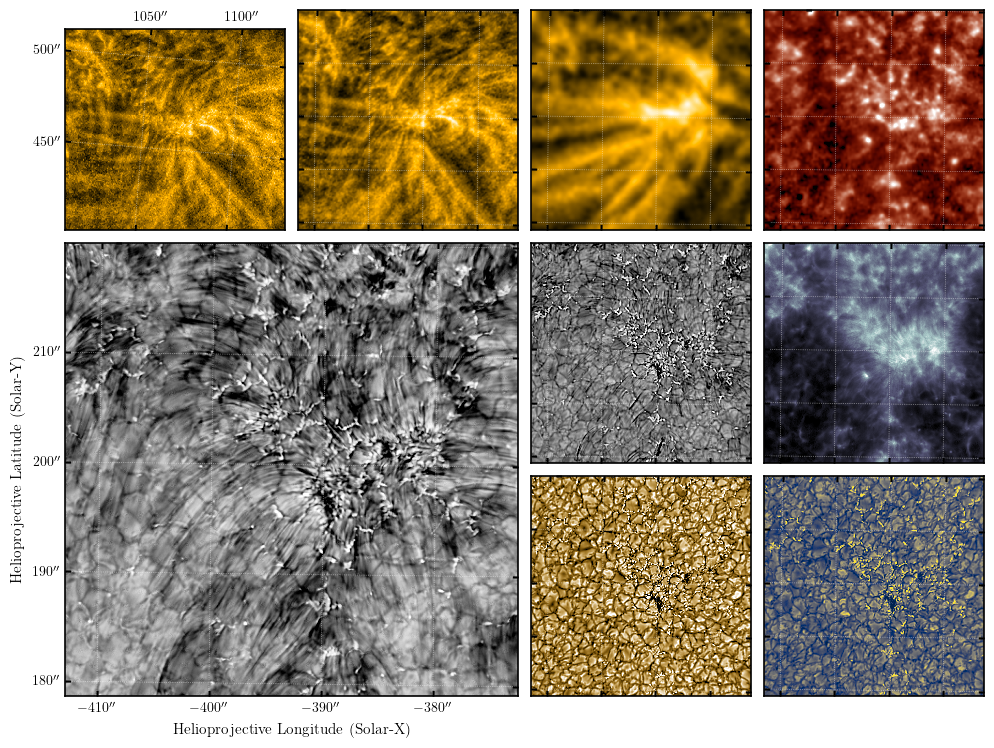

In [20]:
make_movie(save_dir="../../figs/ms_movie/all_channel_layout_movie.mp4", fps=30, dpi=120)